<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_summer_project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('/content/drive/MyDrive/ESAA_OB_pj/customer/seller_master_features.csv')

In [ ]:
df

,seller_id,total_orders,total_revenue,avg_price,price_std,avg_delivery_days,avg_delay_days,delay_rate,avg_installments,unique_categories,top_category,seller_state,review_customer_count,seller_avg_sentiment,seller_sentiment_std,delivery_issue_mean,purchase_issue_mean
0,0015a82c2db000af6aaaf3ae2ecb0532,3,"2,685.00",895.00,0.00,10.33,-16.33,0.00,7.33,1,eletroportateis,SP,3.00,-0.64,0.00,-0.64,0.00
1,001cca7ae9ae17fb1caed9dfb1094831,200,"25,080.03",104.94,16.15,12.63,-13.21,0.05,3.74,2,ferramentas_jardim,ES,195.00,0.09,0.66,-0.63,-0.38
2,001e6ad469a905060d959994f1b41e4f,1,250.00,250.00,0.00,10.69,-12.00,0.00,3.00,1,esporte_lazer,RJ,0.00,0.00,0.00,0.00,0.00
3,002100f778ceb8431b7a1020ff7ab48f,51,"1,234.50",22.45,18.96,15.78,-8.19,0.16,1.46,1,moveis_decoracao,SP,50.00,0.22,0.67,-0.02,-0.56
4,003554e2dce176b5555353e4f3555ac8,1,120.00,120.00,0.00,4.00,-27.00,0.00,3.00,0,Unknown,GO,1.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,1,69.90,69.90,0.00,10.69,-12.00,0.00,1.00,1,livros_interesse_geral,PR,0.00,0.00,0.00,0.00,0.00
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,18,"2,101.20",105.06,66.34,9.80,-12.20,0.00,3.80,2,utilidades_domesticas,PR,18.00,0.41,0.51,0.00,0.07
3092,ffeee66ac5d5a62fe688b9d26f83f534,14,"1,839.86",131.42,14.60,17.64,-8.36,0.14,2.57,1,eletrodomesticos,SP,14.00,0.43,0.64,0.00,0.00
3093,fffd5413c0700ac820c7069d66d98c89,60,"9,062.30",148.56,99.77,13.33,-11.33,0.11,3.57,3,utilidades_domesticas,SP,58.00,0.14,0.72,-0.33,-0.30


#데이터셋 전처리
셀러별 판매 이력 테이블 제작,  
라벨 생성

## 기준시점(cutoff) 생성.


정답 피처(셀러 생존/이탈 여부) 생성 필요.  
셀러별 첫 판매일/마지막 판매일 확인해 라벨 생성 필요함.  

> 셀러별 판매 이력 데이터셋 생성

In [ ]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp'])
items = pd.read_csv('olist_order_items_dataset.csv')

# order_id 기준으로 seller_id + 주문일자 연결
seller_orders = items[['order_id', 'seller_id']].merge(
    orders[['order_id', 'order_purchase_timestamp', 'order_status']],
    on='order_id', how='left'
)

# 셀러별 판매 이력 요약
seller_dates = seller_orders.groupby('seller_id').agg(
    first_sale_date=('order_purchase_timestamp', 'min'),
    last_sale_date=('order_purchase_timestamp', 'max'),
    total_order_count=('order_id', 'nunique')
).reset_index()

seller_dates['activity_span_days'] = (
    seller_dates['last_sale_date'] - seller_dates['first_sale_date']
).dt.days

print(seller_dates.shape)
seller_dates.head()

(3095, 5)


,seller_id,first_sale_date,last_sale_date,total_order_count,activity_span_days
0,0015a82c2db000af6aaaf3ae2ecb0532,2017-09-26 22:17:05,2017-10-18 08:16:34,3,21
1,001cca7ae9ae17fb1caed9dfb1094831,2017-02-04 19:06:04,2018-07-12 21:38:26,200,523
2,001e6ad469a905060d959994f1b41e4f,2018-08-07 22:50:37,2018-08-07 22:50:37,1,0
3,002100f778ceb8431b7a1020ff7ab48f,2017-09-14 01:00:31,2018-04-12 12:58:23,51,210
4,003554e2dce176b5555353e4f3555ac8,2017-12-15 06:52:25,2017-12-15 06:52:25,1,0


판매 기준은 취소/미배송 ~ 배송까지 전부 인정함  
주문 들어온 시점 기준으로 카운트  

> 분포확인

In [ ]:
import matplotlib.pyplot as plt
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

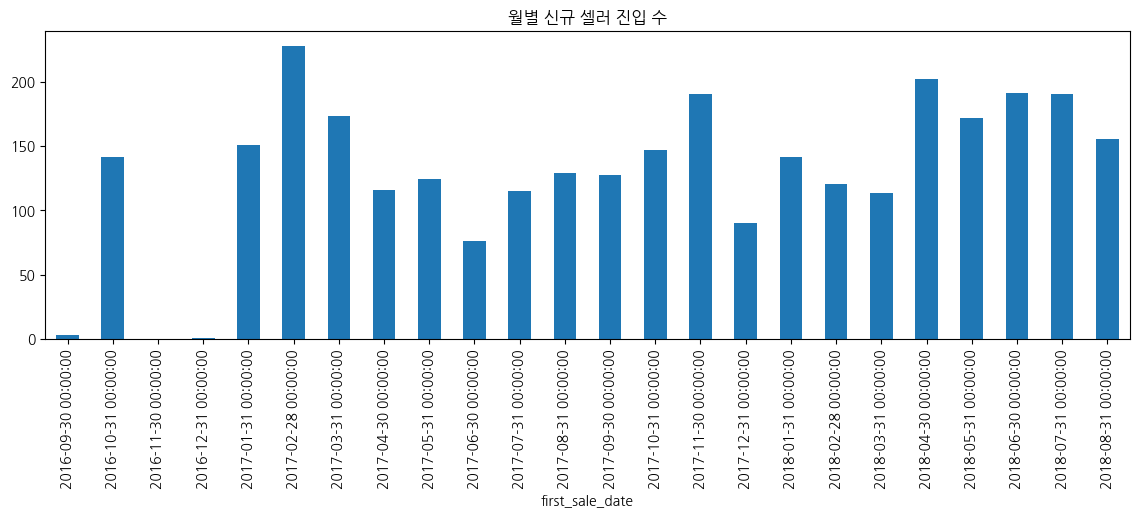

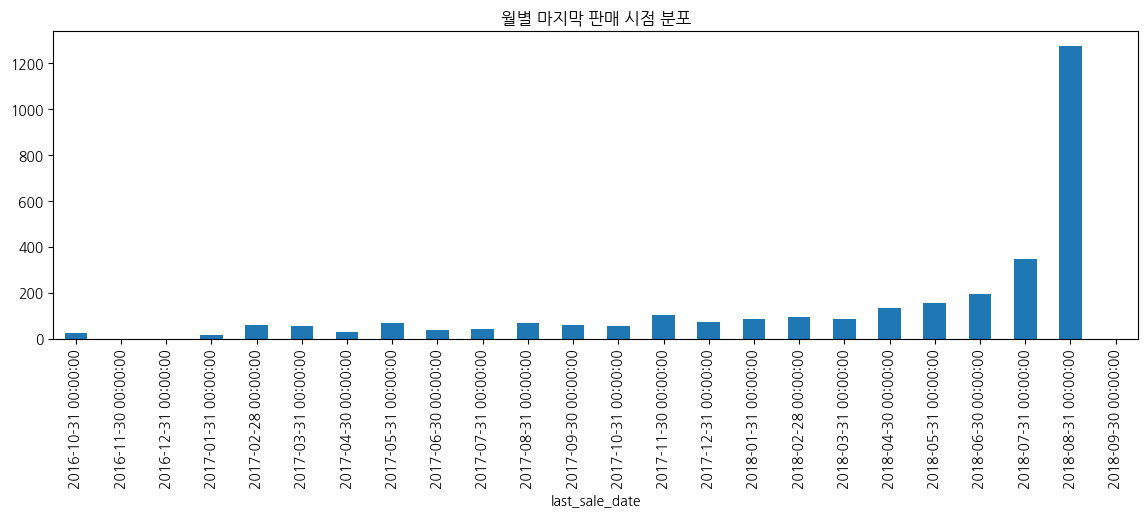

count   3,095.00
mean      175.85
std       181.96
min         0.00
25%        18.00
50%       112.00
75%       287.00
max       709.00
Name: activity_span_days, dtype: float64


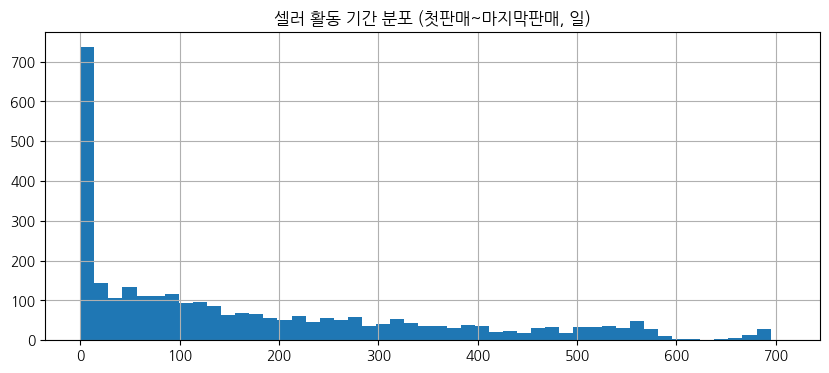

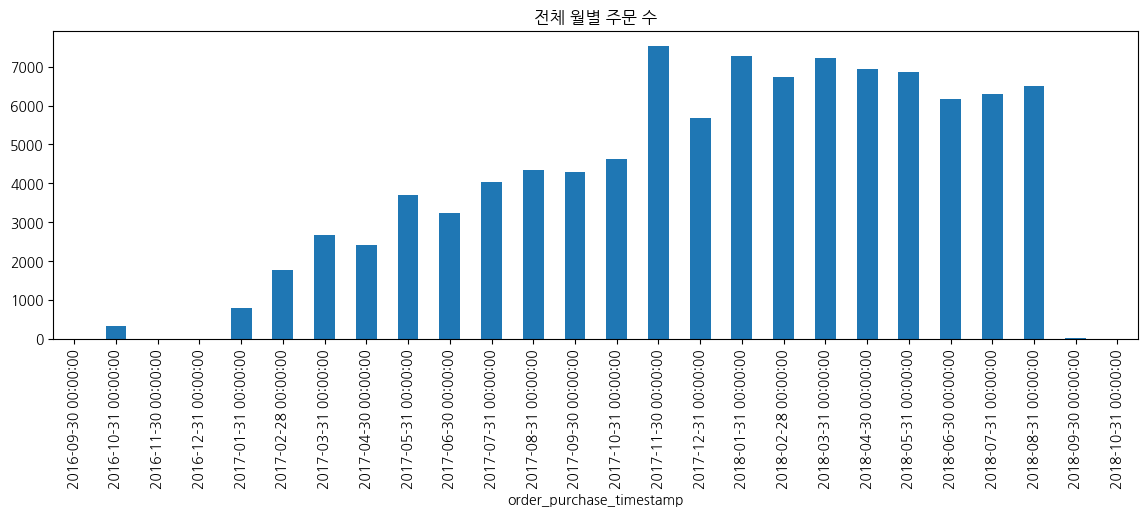

In [ ]:
# 월별 신규 셀러 진입 시점 분포
seller_dates.set_index('first_sale_date').resample('ME').size().plot(kind='bar', figsize=(14,4), title='월별 신규 셀러 진입 수')
plt.show()

# 월별 마지막 판매 시점 분포 (셀러들이 언제 활동을 멈췄는지)
seller_dates.set_index('last_sale_date').resample('ME').size().plot(kind='bar', figsize=(14,4), title='월별 마지막 판매 시점 분포')
plt.show()

# 활동 기간(activity_span_days) 분포
print(seller_dates['activity_span_days'].describe())
seller_dates['activity_span_days'].hist(bins=50, figsize=(10,4))
plt.title('셀러 활동 기간 분포 (첫판매~마지막판매, 일)')
plt.show()

# 전체 주문 기준 월별 주문량도 재확인 (원본 데이터 신뢰 구간 재확인용)
orders.set_index('order_purchase_timestamp').resample('ME').size().plot(kind='bar', figsize=(14,4), title='전체 월별 주문 수')
plt.show()

1. 신규 셀러 진입 대체로 꾸준함
2. 마지막 판매 시점이 2018-08에 몰려있음, 데이터 관측 시점 문제인듯함
3. 활동기간 0일 셀러 매우 많음.
4. 전체 주문량도 2018-08까지 유지되고 09, 10월 급감(관측 시점 문제인듯)

-> 활동기간 0일 셀러는 실질적 판매 수치 부족하다 판단. 단, 하루동안만 판매했던건지 확인 필요.

> cutoff 정하기


In [ ]:
import pandas as pd

# 0일 활동 셀러 제외 (단, total_order_count > 1인데 span=0인 케이스가 있는지 먼저 확인)
same_day_multi = seller_dates[(seller_dates['activity_span_days'] == 0) & (seller_dates['total_order_count'] > 1)]
print(f"같은 날 여러 건 판매 후 끝난 셀러 수: {len(same_day_multi)}")

seller_dates_filtered = seller_dates[seller_dates['activity_span_days'] > 0].copy()
print(f"제외 전: {len(seller_dates)}, 제외 후: {len(seller_dates_filtered)}")

# 유효 데이터 마지막 시점
observation_end = pd.Timestamp('2018-08-31')

cutoff_candidates = ['2018-03-31', '2018-04-30', '2018-05-31', '2018-06-30']

results = []
for cutoff_str in cutoff_candidates:
    cutoff = pd.Timestamp(cutoff_str)

    # cutoff 이전에 이미 활동 시작한 셀러 (분석 대상 후보)
    eligible = seller_dates_filtered[seller_dates_filtered['first_sale_date'] <= cutoff]

    # cutoff 이후 ~ observation_end 사이 실제 판매 여부
    active_after = seller_orders[
        (seller_orders['seller_id'].isin(eligible['seller_id'])) &
        (seller_orders['order_purchase_timestamp'] > cutoff) &
        (seller_orders['order_purchase_timestamp'] <= observation_end)
    ]['seller_id'].unique()

    n_eligible = len(eligible)
    n_active = len(active_after)
    n_churned = n_eligible - n_active

    results.append({
        'cutoff': cutoff_str,
        '관측 대상 셀러 수': n_eligible,
        '관측 가능 기간(일)': (observation_end - cutoff).days,
        'cutoff 이후 활동(생존)': n_active,
        'cutoff 이후 무활동(이탈 후보)': n_churned,
        '이탈률(%)': round(n_churned / n_eligible * 100, 1)
    })

pd.DataFrame(results)

같은 날 여러 건 판매 후 끝난 셀러 수: 16
제외 전: 3095, 제외 후: 2508


,cutoff,관측 대상 셀러 수,관측 가능 기간(일),cutoff 이후 활동(생존),cutoff 이후 무활동(이탈 후보),이탈률(%)
0,2018-03-31,1867,153,1205,662,35.50
1,2018-04-30,2031,123,1269,762,37.50
2,2018-05-31,2168,92,1287,881,40.60
3,2018-06-30,2311,62,1282,1029,44.50


16명은 하루동안만 판매함. 수가 크지 않아 표본에서 제외. -> 활동기간 0일 셀러는 분석 대상에서 전부 제외

재구매 고객들의 재구매까지 걸린 기간이 중앙값 34일, 75%가 141일 이내 ... -> 셀러 판매 기간도 대략 90~120일은 되어야할 듯함.  

표본수 확보 및 이탈률 관점에서 '2018-04-30' 선정.


In [ ]:
cutoff = pd.Timestamp('2018-04-30')
observation_end = pd.Timestamp('2018-08-31')

# cutoff 이전 활동 시작 + 활동기간 0일 제외된 셀러 중에서
eligible = seller_dates_filtered[seller_dates_filtered['first_sale_date'] <= cutoff].copy()

# cutoff 이후 ~ observation_end 사이 판매 여부로 라벨링
active_after = seller_orders[
    (seller_orders['seller_id'].isin(eligible['seller_id'])) &
    (seller_orders['order_purchase_timestamp'] > cutoff) &
    (seller_orders['order_purchase_timestamp'] <= observation_end)
]['seller_id'].unique()

eligible['is_active'] = eligible['seller_id'].isin(active_after).astype(int)
eligible['churned'] = 1 - eligible['is_active']

# 라벨을 seller_master_features.csv에 merge
seller_master = pd.read_csv('seller_master_features.csv')
final_df = seller_master.merge(eligible[['seller_id', 'churned']], on='seller_id', how='inner')

print(final_df.shape)
print(final_df['churned'].value_counts(normalize=True))

(2031, 18)
churned
0   0.62
1   0.38
Name: proportion, dtype: float64


심한 불균형은 없음!

cutoff 기준으로 앞뒤 기간 분리, 피처 재계산하면 좋겠지만 ...
일단 전달받은 데이터셋 피처 그대로 사용 예정  
(피처를 시간 순서로 분리하지 않아 누수 가능성이 있으며, 모델 성능이 실제보다 낙관적으로 나올 수 있음)

# 모델링 준비

=== 왜도(skewness) 재확인 (final_df 기준) ===
total_orders: skew=7.96
total_revenue: skew=7.48
avg_price: skew=5.66
price_std: skew=8.19
avg_delivery_days: skew=2.72
avg_delay_days: skew=-0.06

       total_orders  total_revenue  avg_price  price_std  avg_delivery_days  \
count      2,031.00       2,031.00   2,031.00   2,031.00           2,031.00   
mean          46.95       6,338.53     172.37      90.85              12.49   
std          127.20      16,821.72     265.91     170.42               5.53   
min            2.00          12.00       6.00       0.00               1.50   
25%            5.00         523.50      55.93      15.92               9.28   
50%           12.00       1,678.14      98.50      43.34              11.57   
75%           39.00       5,415.98     175.59      93.48              14.25   
max        1,854.00     229,472.63   3,360.00   3,841.74              66.33   

       avg_delay_days  
count        2,031.00  
mean           -12.39  
std              6.35  
min  

<Axes: >

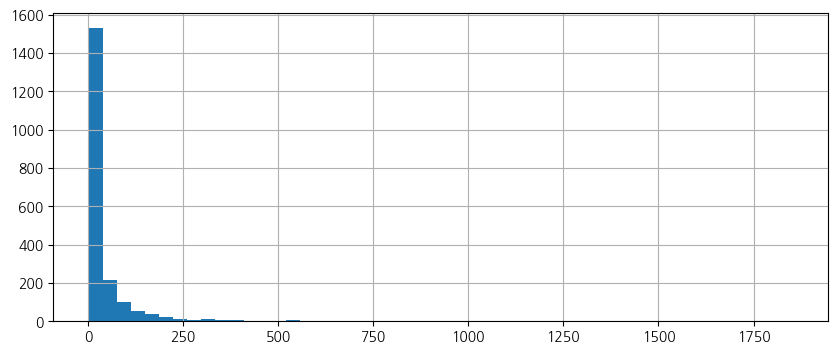

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 로그변환 대상 재확인
skew_cols = ['total_orders', 'total_revenue', 'avg_price', 'price_std',
             'avg_delivery_days', 'avg_delay_days']

print("=== 왜도(skewness) 재확인 (final_df 기준) ===")
for c in skew_cols:
    print(f"{c}: skew={final_df[c].skew():.2f}")

print()
print(final_df[skew_cols].describe())

# 셀러별 판매건수(total_orders) 분포 재확인
print()
print("=== total_orders 분포 (final_df, n=2031) ===")
print(final_df['total_orders'].describe())
print()
print("10건 미만 셀러 수:", (final_df['total_orders'] < 10).sum(),
      f"({(final_df['total_orders'] < 10).mean()*100:.1f}%)")

# churned 여부에 따라 주문건수 분포가 다른지도 같이 확인
print()
print("=== churned 여부별 total_orders 비교 ===")
print(final_df.groupby('churned')['total_orders'].describe())

# 히스토그램
final_df['total_orders'].hist(bins=50, figsize=(10,4))

churned 여부별 주문수 비교
- churned=0 (생존): 중앙값 22건, 75% 62건
- churned=1 (이탈): 중앙값  5건, 75% 11건

차이가 뚜렷하지만... 기준 시점 상관없이 집계한것이라 자연스럽게 누적 주문수 늘었을 가능성 있음

이탈 클래스 표본 유지 위해 필터링 취소

> 로그변환 왜도 완화

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score

# 로그변환
log_cols = ['total_orders', 'total_revenue', 'avg_price', 'price_std', 'avg_delivery_days']
for c in log_cols:
    final_df[f'{c}_log'] = np.log1p(final_df[c])

# 범주형 인코딩
# seller_state: 카디널리티 낮음(~27개) 원-핫
state_dummies = pd.get_dummies(final_df['seller_state'], prefix='state', drop_first=True)

# top_category: 카디널리티 높을 수 있음 → 상위 10개 + 기타로 묶은 뒤 원-핫
top10_categories = final_df['top_category'].value_counts().nlargest(10).index
final_df['top_category_grouped'] = final_df['top_category'].apply(
    lambda x: x if x in top10_categories else '기타'
)
category_dummies = pd.get_dummies(final_df['top_category_grouped'], prefix='cat', drop_first=True)

print("seller_state 카디널리티:", final_df['seller_state'].nunique())
print("top_category 카디널리티:", final_df['top_category'].nunique())
print("상위 10개 카테고리:", list(top10_categories))

# 최종 피처셋 구성
numeric_features = [
    'total_orders_log', 'total_revenue_log', 'avg_price_log', 'price_std_log',
    'avg_delivery_days_log', 'avg_delay_days', 'delay_rate', 'avg_installments',
    'unique_categories', 'review_customer_count', 'seller_avg_sentiment',
    'seller_sentiment_std', 'delivery_issue_mean', 'purchase_issue_mean'
]

X = pd.concat([final_df[numeric_features], state_dummies, category_dummies], axis=1)
y = final_df['churned']

print("\n최종 피처 수:", X.shape[1])
print("결측치 확인:", X.isnull().sum().sum())

#  train/test 분할 (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\ntrain: {X_train.shape}, test: {X_test.shape}")
print("train churned 비율:", y_train.mean().round(3))
print("test churned 비율:", y_test.mean().round(3))

# 베이스라인: 로지스틱 회귀 (스케일링 필요)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("\n=== 베이스라인 로지스틱 회귀 결과 ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("F1-score:", round(f1_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))

# 계수 확인
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print("\n=== 영향력 큰 피처 top 10 ===")
print(coef_df.head(10))

seller_state 카디널리티: 22
top_category 카디널리티: 68
상위 10개 카테고리: ['esporte_lazer', 'beleza_saude', 'utilidades_domesticas', 'moveis_decoracao', 'automotivo', 'informatica_acessorios', 'cama_mesa_banho', 'brinquedos', 'ferramentas_jardim', 'bebes']

최종 피처 수: 45
결측치 확인: 0

train: (1624, 45), test: (407, 45)
train churned 비율: 0.375
test churned 비율: 0.376

=== 베이스라인 로지스틱 회귀 결과 ===
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       254
           1       0.73      0.64      0.68       153

    accuracy                           0.77       407
   macro avg       0.76      0.75      0.75       407
weighted avg       0.77      0.77      0.77       407

ROC-AUC: 0.836
F1-score: 0.681
Recall: 0.641

=== 영향력 큰 피처 top 10 ===
                       feature  coefficient
1            total_revenue_log        -1.00
4        avg_delivery_days_log         0.67
5               avg_delay_days        -0.30
2                avg_price_log         0.28
41  cat_i

total_revenue_log는 구조적 관계에 가까움  

avg_delivery_days_log: +0.67  → 평균 배송일이 길수록 이탈 확률 ↑  
avg_price_log:         +0.28  → 평균 가격이 높을수록 이탈 확률 ↑  
delay_rate:            -0.24  → (아래에서 같이 설명)  
category 더미들:        +0.24~0.25 (특정 카테고리가 기준 카테고리 대비 이탈 위험 높음)

> XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
from sklearn.model_selection import RandomizedSearchCV

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

search = RandomizedSearchCV(
    xgb_clf, param_distributions=param_dist,
    n_iter=30, scoring='roc_auc', cv=5,
    random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

best_xgb = search.best_estimator_
print("최적 파라미터:", search.best_params_)

# 평가
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost 결과 ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb), 3))
print("F1-score:", round(f1_score(y_test, y_pred_xgb), 3))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 3))

# 로지스틱 회귀 vs XGBoost 비교표
comparison = pd.DataFrame({
    '모델': ['로지스틱 회귀', 'XGBoost'],
    'ROC-AUC': [0.836, round(roc_auc_score(y_test, y_proba_xgb), 3)],
    'F1-score': [0.681, round(f1_score(y_test, y_pred_xgb), 3)],
    'Recall': [0.641, round(recall_score(y_test, y_pred_xgb), 3)]
})
print("\n", comparison)

# 피처 중요도
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)
print("\n=== 피처 중요도 top 10 ===")
print(importance_df.head(10))

최적 파라미터: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

=== XGBoost 결과 ===
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       254
           1       0.74      0.65      0.69       153

    accuracy                           0.78       407
   macro avg       0.77      0.76      0.76       407
weighted avg       0.78      0.78      0.78       407

ROC-AUC: 0.839
F1-score: 0.692
Recall: 0.654

         모델  ROC-AUC  F1-score  Recall
0  로지스틱 회귀     0.84      0.68    0.64
1  XGBoost     0.84      0.69    0.65

=== 피처 중요도 top 10 ===
                  feature  importance
9   review_customer_count        0.21
0        total_orders_log        0.11
11   seller_sentiment_std        0.05
1       total_revenue_log        0.04
4   avg_delivery_days_log        0.04
6              delay_rate        0.03
39      cat_esporte_lazer        0.03
37         cat_brinquedos    

성능 한계인듯 .. ? 어쩔수없이 cutoff 기준으로 다시 생성할게요 ...

## 누수 피처 보완

cutoff 기준으로 피처 계산 안 했더니 예측 오류 큼. 모델 성능이 인사이트인게 아니라 누수 피처때문인것

> cutoff 기준으로 피처 재계산
- 피처 중요도 높은 피처들 3개 기준으로 다시 진행
- 그 외는 평균/비율 성격 피처라 왜곡도 상대적으로 적음. 일단 유지

In [ ]:
import pandas as pd

cutoff = pd.Timestamp('2018-04-30')


# total_orders (cutoff 이전 주문 수만)
orders_before_cutoff = seller_orders[seller_orders['order_purchase_timestamp'] <= cutoff]

total_orders_cutoff = orders_before_cutoff.groupby('seller_id')['order_id'].nunique().reset_index()
total_orders_cutoff.columns = ['seller_id', 'total_orders_cutoff']

# total_revenue (cutoff 이전 결제금액만)
# order_items의 price 컬럼 필요
items_price = items[['order_id', 'seller_id', 'price']]  # 위에서 이미 로드한 items 활용

revenue_before_cutoff = items_price.merge(
    orders[['order_id', 'order_purchase_timestamp']], on='order_id'
)
revenue_before_cutoff = revenue_before_cutoff[
    revenue_before_cutoff['order_purchase_timestamp'] <= cutoff
]

total_revenue_cutoff = revenue_before_cutoff.groupby('seller_id')['price'].sum().reset_index()
total_revenue_cutoff.columns = ['seller_id', 'total_revenue_cutoff']

# review_customer_count (cutoff 이전 주문에 달린 리뷰 수만)
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

# order_id -> seller_id 매핑 (한 주문에 여러 셀러 가능하니 order_items 기준)
review_seller_map = reviews[['order_id', 'review_id']].merge(
    items[['order_id', 'seller_id']], on='order_id'
).merge(
    orders[['order_id', 'order_purchase_timestamp']], on='order_id'
)

review_seller_map_cutoff = review_seller_map[
    review_seller_map['order_purchase_timestamp'] <= cutoff
]

review_count_cutoff = review_seller_map_cutoff.groupby('seller_id')['review_id'].nunique().reset_index()
review_count_cutoff.columns = ['seller_id', 'review_customer_count_cutoff']

# final_df에 병합 (기존 lifetime 컬럼은 남겨두고 _cutoff 버전 추가)
final_df = final_df.merge(total_orders_cutoff, on='seller_id', how='left')
final_df = final_df.merge(total_revenue_cutoff, on='seller_id', how='left')
final_df = final_df.merge(review_count_cutoff, on='seller_id', how='left')

# cutoff 이전 활동/리뷰가 아예 없는 셀러는 0으로 채움
for c in ['total_orders_cutoff', 'total_revenue_cutoff', 'review_customer_count_cutoff']:
    final_df[c] = final_df[c].fillna(0)

# 확인
print(final_df[['seller_id', 'total_orders', 'total_orders_cutoff',
                 'total_revenue', 'total_revenue_cutoff',
                 'review_customer_count', 'review_customer_count_cutoff']].describe())

# 기존 값 대비 얼마나 줄었는지 확인
print("\ntotal_orders 평균 변화:", final_df['total_orders'].mean(), "->", final_df['total_orders_cutoff'].mean())
print("total_revenue 평균 변화:", final_df['total_revenue'].mean(), "->", final_df['total_revenue_cutoff'].mean())
print("review_count 평균 변화:", final_df['review_customer_count'].mean(), "->", final_df['review_customer_count_cutoff'].mean())

       total_orders  total_orders_cutoff  total_revenue  total_revenue_cutoff  \
count      2,031.00             2,031.00       2,031.00              2,031.00   
mean          46.95                36.05       6,338.53              4,855.17   
std          127.20               101.40      16,821.72             13,643.71   
min            2.00                 1.00          12.00                  7.99   
25%            5.00                 3.00         523.50                351.90   
50%           12.00                 9.00       1,678.14              1,213.00   
75%           39.00                28.00       5,415.98              3,842.83   
max        1,854.00             1,566.00     229,472.63            196,508.85   

       review_customer_count  review_customer_count_cutoff  
count               2,031.00                      2,031.00  
mean                   45.54                         35.89  
std                   123.62                        100.98  
min                     0.

In [ ]:
import numpy as np

# 기존 lifetime 컬럼을 cutoff 버전으로 교체
final_df['total_orders_log'] = np.log1p(final_df['total_orders_cutoff'])
final_df['total_revenue_log'] = np.log1p(final_df['total_revenue_cutoff'])
final_df['review_customer_count'] = final_df['review_customer_count_cutoff']  # 로그변환 안 했던 원래 그대로

# X 피처셋 재구성 (numeric_features 리스트는 그대로 컬럼명 유지되니 재사용 가능)
X = pd.concat([final_df[numeric_features], state_dummies, category_dummies], axis=1)
y = final_df['churned']

# train/test 재분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# XGBoost 재학습 (이전 best_params 그대로 사용)
best_xgb.fit(X_train, y_train)

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
print("=== cutoff 반영 후 XGBoost 결과 ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb), 3))
print("F1-score:", round(f1_score(y_test, y_pred_xgb), 3))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 3))

# 피처 중요도 재확인 (가장 중요하게 볼 부분)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)
print("\n=== 피처 중요도 top 10 (cutoff 반영 후) ===")
print(importance_df.head(10))

=== cutoff 반영 후 XGBoost 결과 ===
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       254
           1       0.81      0.59      0.68       153

    accuracy                           0.79       407
   macro avg       0.80      0.75      0.77       407
weighted avg       0.80      0.79      0.79       407

ROC-AUC: 0.836
F1-score: 0.684
Recall: 0.595

=== 피처 중요도 top 10 (cutoff 반영 후) ===
                  feature  importance
11   seller_sentiment_std        0.14
0        total_orders_log        0.10
9   review_customer_count        0.09
6              delay_rate        0.08
13    purchase_issue_mean        0.06
4   avg_delivery_days_log        0.05
12    delivery_issue_mean        0.04
8       unique_categories        0.04
10   seller_avg_sentiment        0.04
3           price_std_log        0.04


다시 만든 피처들 중요도 변화보임. 누수 줄었음

seller_sentiment_std(감성 변동성), delay_rate(지연율), purchase_issue_mean(구매 이슈 강도) 같은 실제 셀러 운영 특성이 예측에 기여하는 비중이 커진 것

예측 성능도 거의 비슷.
파라미터 튜닝 ㄱㄱ

In [ ]:
 !pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.1 MB/s eta 0:00:00


### XGB 모델링

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
    }

    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

# 최적 파라미터로 재학습
best_xgb = xgb.XGBClassifier(**study.best_params, objective='binary:logistic',
                               eval_metric='logloss', random_state=42)
best_xgb.fit(X_train, y_train)

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
print("\n=== Optuna 튜닝 후 결과 ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb), 3))
print("F1-score:", round(f1_score(y_test, y_pred_xgb), 3))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 3))

[I 2026-07-31 07:19:15,849] A new study created in memory with name: no-name-83998b62-9b18-4b9f-b0d5-611ebdb67bcf


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-31 07:19:17,285] Trial 0 finished with value: 0.6213451659636883 and parameters: {'n_estimators': 314, 'max_depth': 3, 'learning_rate': 0.005840789588267967, 'subsample': 0.6573405777874732, 'colsample_bytree': 0.9291748714843054, 'min_child_weight': 4, 'gamma': 0.4359931113388765, 'reg_alpha': 1.1148515478983079, 'reg_lambda': 1.6309994084133739}. Best is trial 0 with value: 0.6213451659636883.
[I 2026-07-31 07:19:18,273] Trial 1 finished with value: 0.5843382886219665 and parameters: {'n_estimators': 135, 'max_depth': 8, 'learning_rate': 0.005408937300438882, 'subsample': 0.8209559178132474, 'colsample_bytree': 0.9869397825519683, 'min_child_weight': 4, 'gamma': 1.6545003348212484, 'reg_alpha': 1.774097386223032, 'reg_lambda': 0.4920793555862846}. Best is trial 0 with value: 0.6213451659636883.
[I 2026-07-31 07:19:19,438] Trial 2 finished with value: 0.6546680188427787 and parameters: {'n_estimators': 433, 'max_depth': 3, 'learning_rate': 0.013921627418776937, 'subsample':

ㄱㅊㄱㅊ아짐

=== 튜닝 후 최종 피처 중요도 top 10 ===
                  feature  importance
11   seller_sentiment_std        0.12
9   review_customer_count        0.11
6              delay_rate        0.09
0        total_orders_log        0.08
4   avg_delivery_days_log        0.05
12    delivery_issue_mean        0.04
13    purchase_issue_mean        0.04
8       unique_categories        0.04
10   seller_avg_sentiment        0.04
20               state_MG        0.04

=== 5-Fold CV 결과 (분할별 편차 확인) ===
F1: [0.69  0.65  0.725 0.717 0.678] 평균: 0.692
AUC: [0.852 0.815 0.843 0.866 0.827] 평균: 0.84
Recall: [0.634 0.588 0.684 0.691 0.651] 평균: 0.65

=== 과적합 확인 ===
Train F1: 0.832 vs Test F1: 0.709
Train AUC: 0.950 vs Test AUC: 0.833


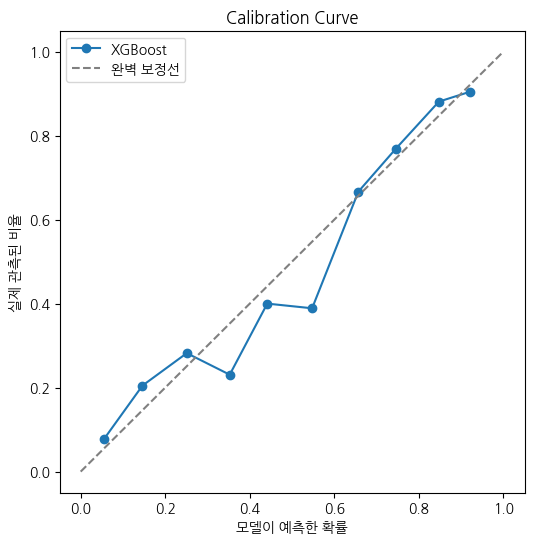


=== state/category 더미별 표본 수 (너무 적은 조합 확인) ===
seller_state
RO    2
MA    1
AM    1
PI    1
PA    1
Name: count, dtype: int64
top_category_grouped
informatica_acessorios    110
cama_mesa_banho            92
brinquedos                 83
ferramentas_jardim         66
bebes                      62
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
import xgboost as xgb

# 최종 확정 모델
final_params = study.best_params
final_params.update({'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42})
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train)

# 튜닝 후 피처 중요도 재확인
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)
print("=== 튜닝 후 최종 피처 중요도 top 10 ===")
print(importance_df.head(10))

#5-fold CV로 안정성 확인 (여러 분할에서 일관된 성능인지)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(final_model, X, y, cv=cv, scoring=['f1', 'roc_auc', 'recall'])
print("\n=== 5-Fold CV 결과 (분할별 편차 확인) ===")
print("F1:", cv_results['test_f1'].round(3), "평균:", cv_results['test_f1'].mean().round(3))
print("AUC:", cv_results['test_roc_auc'].round(3), "평균:", cv_results['test_roc_auc'].mean().round(3))
print("Recall:", cv_results['test_recall'].round(3), "평균:", cv_results['test_recall'].mean().round(3))

# Train vs Test 성능 비교 (과적합 확인)
from sklearn.metrics import f1_score, roc_auc_score
train_f1 = f1_score(y_train, final_model.predict(X_train))
train_auc = roc_auc_score(y_train, final_model.predict_proba(X_train)[:,1])
print(f"\n=== 과적합 확인 ===")
print(f"Train F1: {train_f1:.3f} vs Test F1: 0.709")
print(f"Train AUC: {train_auc:.3f} vs Test AUC: 0.833")

# Calibration curve (확률 신뢰도 확인)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_proba_test = final_model.predict_proba(X_test)[:,1]
prob_true, prob_pred = calibration_curve(y_test, y_proba_test, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='완벽 보정선')
plt.xlabel('모델이 예측한 확률')
plt.ylabel('실제 관측된 비율')
plt.legend()
plt.title('Calibration Curve')
plt.show()

# 더미 변수 표본 크기 확인
print("\n=== state/category 더미별 표본 수 (너무 적은 조합 확인) ===")
print(final_df['seller_state'].value_counts().tail(5))
print(final_df['top_category_grouped'].value_counts().tail(5))

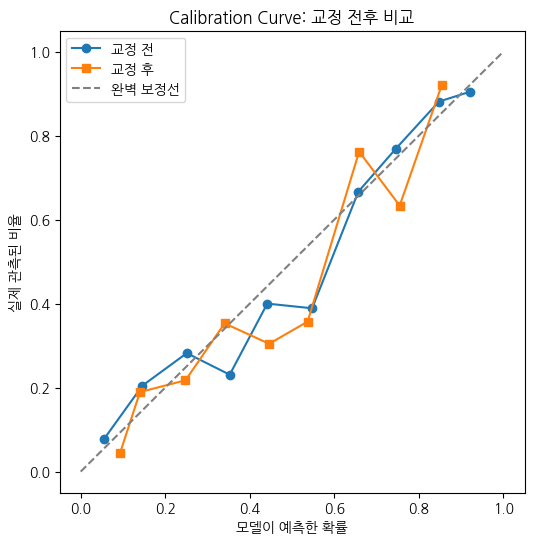

교정 후 F1: 0.693
교정 후 AUC: 0.832


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# 표본이 작으니 파라미터 많은 isotonic보다 sigmoid(Platt)가 더 안전
calibrated_model = CalibratedClassifierCV(final_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

y_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# 교정 전후 비교
prob_true_before, prob_pred_before = calibration_curve(y_test, y_proba_test, n_bins=10)
prob_true_after, prob_pred_after = calibration_curve(y_test, y_proba_calibrated, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_before, prob_true_before, marker='o', label='교정 전')
plt.plot(prob_pred_after, prob_true_after, marker='s', label='교정 후')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='완벽 보정선')
plt.xlabel('모델이 예측한 확률')
plt.ylabel('실제 관측된 비율')
plt.legend()
plt.title('Calibration Curve: 교정 전후 비교')
plt.show()

from sklearn.metrics import f1_score, roc_auc_score
y_pred_calibrated = calibrated_model.predict(X_test)
print("교정 후 F1:", round(f1_score(y_test, y_pred_calibrated), 3))
print("교정 후 AUC:", round(roc_auc_score(y_test, y_proba_calibrated), 3))

Calibration 개선 확인  
state별 표본이 매우 적은 경우 있어서 표본 적은 state는 기타로 그룹핑해버리기 .

=== state별 표본 수 ===
seller_state
SP    1240
PR     236
MG     161
SC     116
RJ     103
RS      79
DF      26
GO      19
ES      10
BA       9
PE       7
CE       5
MS       4
MT       3
RN       3
PB       2
SE       2
RO       2
MA       1
AM       1
PI       1
PA       1
Name: count, dtype: int64

재그룹핑 후 state 분포:
seller_state_grouped
SP    1240
PR     236
MG     161
SC     116
RJ     103
RS      79
기타      70
DF      26
Name: count, dtype: int64

=== top_category_grouped별 표본 수 (20개 기준 재점검) ===
top_category_grouped
기타                        796
esporte_lazer             213
beleza_saude              189
utilidades_domesticas     155
moveis_decoracao          146
automotivo                119
informatica_acessorios    110
cama_mesa_banho            92
brinquedos                 83
ferramentas_jardim         66
bebes                      62
Name: count, dtype: int64

최종 피처 수: 31
state 더미 개수: 7
category 더미 개수: 10

=== state 재그룹핑 반영 후 최종 결과 ===
              precision    recall  f1-scor

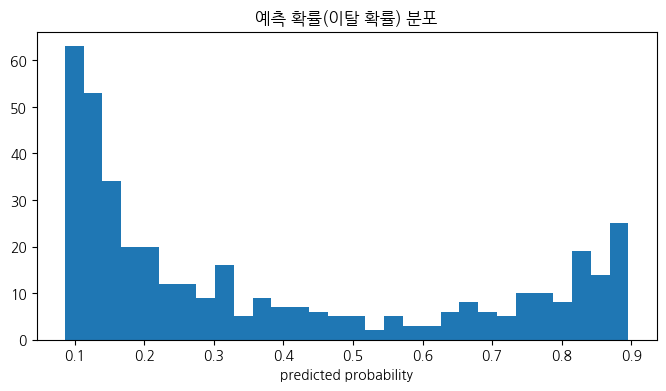

0.05 미만 예측 건수: 0
0.95 초과 예측 건수: 0
전체 대비 극단값 비율: 0.0 %


In [ ]:
import pandas as pd
import numpy as np

# seller_state 재그룹핑 (표본 20개 미만 → 기타)
state_counts = final_df['seller_state'].value_counts()
print("=== state별 표본 수 ===")
print(state_counts)

valid_states = state_counts[state_counts >= 20].index
final_df['seller_state_grouped'] = final_df['seller_state'].apply(
    lambda x: x if x in valid_states else '기타'
)
print("\n재그룹핑 후 state 분포:")
print(final_df['seller_state_grouped'].value_counts())

# top_category 표본 수도 같이 재확인
print("\n=== top_category_grouped별 표본 수 (20개 기준 재점검) ===")
print(final_df['top_category_grouped'].value_counts())

# 더미 재생성 + X 재구성
state_dummies = pd.get_dummies(final_df['seller_state_grouped'], prefix='state', drop_first=True)
category_dummies = pd.get_dummies(final_df['top_category_grouped'], prefix='cat', drop_first=True)

X = pd.concat([final_df[numeric_features], state_dummies, category_dummies], axis=1)
y = final_df['churned']

print("\n최종 피처 수:", X.shape[1])
print("state 더미 개수:", len([c for c in X.columns if c.startswith('state_')]))
print("category 더미 개수:", len([c for c in X.columns if c.startswith('cat_')]))


# train/test 재분할 + 모델 재학습 (Optuna best_params 그대로 사용)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

import xgboost as xgb
final_params = study.best_params
final_params.update({'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42})
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train)

from sklearn.calibration import CalibratedClassifierCV
calibrated_model = CalibratedClassifierCV(final_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

y_pred = calibrated_model.predict(X_test)
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score, f1_score
print("\n=== state 재그룹핑 반영 후 최종 결과 ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("F1-score:", round(f1_score(y_test, y_pred), 3))

# 예측 확률 극단값 분포 확인
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(y_proba, bins=30)
plt.title('예측 확률(이탈 확률) 분포')
plt.xlabel('predicted probability')
plt.show()

print("0.05 미만 예측 건수:", (y_proba < 0.05).sum())
print("0.95 초과 예측 건수:", (y_proba > 0.95).sum())
print("전체 대비 극단값 비율:", round(((y_proba < 0.05) | (y_proba > 0.95)).mean() * 100, 1), "%")

그룹핑 후 피처 감소, 성능 유지+F1 개선  
노이즈 감소!  

히스토그램 해석) 극단적 예측 많이 줄어듦.

극단값도 없음!

> Calibration 재확인

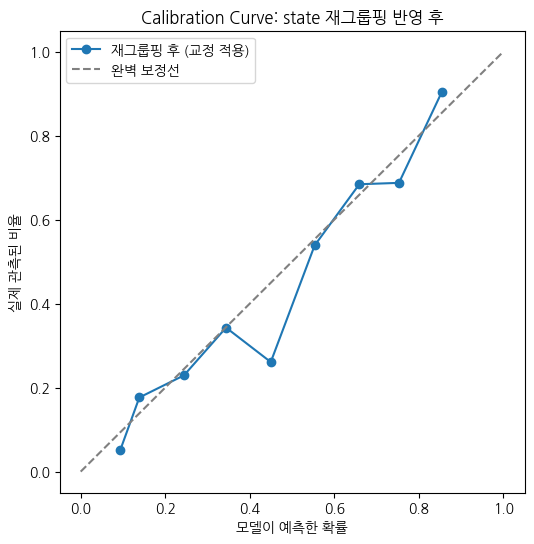

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='재그룹핑 후 (교정 적용)')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='완벽 보정선')
plt.xlabel('모델이 예측한 확률')
plt.ylabel('실제 관측된 비율')
plt.legend()
plt.title('Calibration Curve: state 재그룹핑 반영 후')
plt.show()

대각선에 가까워진듯 + 아래로 좀 처져있는 구간이 있긴 함  
표본이 적어서 생기는 아쉬움 존재

> treshold 조정 시도

기본 threshold(0.5) F1: 0.703
최적 threshold(0.522) F1: 0.708
이때 Precision: 0.790, Recall: 0.641


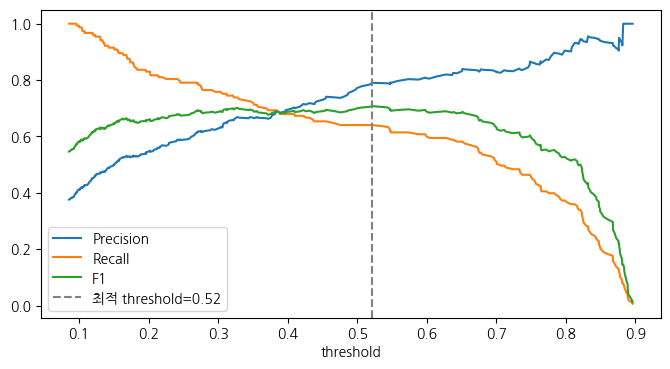

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# threshold별 F1 계산해서 최적점 탐색
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = f1_scores[:-1].argmax()  # thresholds는 precisions/recalls보다 1개 적음
best_threshold = thresholds[best_idx]

print(f"기본 threshold(0.5) F1: {f1_score(y_test, (y_proba >= 0.5).astype(int)):.3f}")
print(f"최적 threshold({best_threshold:.3f}) F1: {f1_scores[best_idx]:.3f}")
print(f"이때 Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}")

plt.figure(figsize=(8,4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(best_threshold, linestyle='--', color='gray', label=f'최적 threshold={best_threshold:.2f}')
plt.xlabel('threshold')
plt.legend()
plt.show()

treshold 기본값이랑 조정값 차이가 크진 않아서 그대로 넘어가기로 결정

### LGBM 모델링

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective_lgb(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'random_state': 42,
        'verbosity': -1,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
    }

    model = lgb.LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    return scores.mean()

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

print("Best F1 (LightGBM):", study_lgb.best_value)
print("Best params:", study_lgb.best_params)

# 최적 파라미터로 학습
best_lgb = lgb.LGBMClassifier(**study_lgb.best_params, objective='binary',
                                metric='binary_logloss', random_state=42, verbosity=-1)
best_lgb.fit(X_train, y_train)

y_pred_lgb = best_lgb.predict(X_test)
y_proba_lgb = best_lgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print("\n=== LightGBM 결과 ===")
print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lgb), 3))
print("F1-score:", round(f1_score(y_test, y_pred_lgb), 3))

[I 2026-07-31 07:21:38,327] A new study created in memory with name: no-name-5e8c0a28-99e5-4646-b079-3fc2cd77a7cc


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-31 07:21:38,860] Trial 0 finished with value: 0.6798479871040859 and parameters: {'n_estimators': 163, 'max_depth': 6, 'learning_rate': 0.04465283709459719, 'num_leaves': 83, 'subsample': 0.9558667968557828, 'colsample_bytree': 0.720208911745975, 'min_child_samples': 19, 'reg_alpha': 4.1580628330232425, 'reg_lambda': 2.965614037555833}. Best is trial 0 with value: 0.6798479871040859.
[I 2026-07-31 07:21:39,296] Trial 1 finished with value: 0.6800913369375581 and parameters: {'n_estimators': 296, 'max_depth': 8, 'learning_rate': 0.15934208804444955, 'num_leaves': 100, 'subsample': 0.6928709519339074, 'colsample_bytree': 0.607479718749313, 'min_child_samples': 5, 'reg_alpha': 3.77098645969344, 'reg_lambda': 3.394662250148475}. Best is trial 1 with value: 0.6800913369375581.
[I 2026-07-31 07:21:39,905] Trial 2 finished with value: 0.6484474784493816 and parameters: {'n_estimators': 421, 'max_depth': 3, 'learning_rate': 0.008959631669676634, 'num_leaves': 24, 'subsample': 0.7610

> XGB, LGBM 동일조건에서 비교하는 코드

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV

# XGBoost 교정 전(raw) 값 확인
y_pred_xgb_raw = final_model.predict(X_test)
y_proba_xgb_raw = final_model.predict_proba(X_test)[:, 1]
print("XGBoost (교정 전) F1:", round(f1_score(y_test, y_pred_xgb_raw), 3))
print("XGBoost (교정 전) AUC:", round(roc_auc_score(y_test, y_proba_xgb_raw), 3))

# LightGBM도 동일하게 교정 적용
calibrated_lgb = CalibratedClassifierCV(best_lgb, method='sigmoid', cv=5)
calibrated_lgb.fit(X_train, y_train)

y_pred_lgb_cal = calibrated_lgb.predict(X_test)
y_proba_lgb_cal = calibrated_lgb.predict_proba(X_test)[:, 1]
print("\nLightGBM (교정 후) F1:", round(f1_score(y_test, y_pred_lgb_cal), 3))
print("LightGBM (교정 후) AUC:", round(roc_auc_score(y_test, y_proba_lgb_cal), 3))

# 최종 비교표 (교정 전/후 모두)
comparison = pd.DataFrame({
    '모델': ['XGBoost (교정 전)', 'XGBoost (교정 후)', 'LightGBM (교정 전)', 'LightGBM (교정 후)'],
    'F1': [
        f1_score(y_test, y_pred_xgb_raw),
        0.700,
        0.704,
        f1_score(y_test, y_pred_lgb_cal)
    ],
    'AUC': [
        roc_auc_score(y_test, y_proba_xgb_raw),
        0.831,
        0.836,
        roc_auc_score(y_test, y_proba_lgb_cal)
    ]
})
print("\n", comparison.round(3))

XGBoost (교정 전) F1: 0.692
XGBoost (교정 전) AUC: 0.832

LightGBM (교정 후) F1: 0.698
LightGBM (교정 후) AUC: 0.827

                 모델   F1  AUC
0   XGBoost (교정 전) 0.69 0.83
1   XGBoost (교정 후) 0.70 0.83
2  LightGBM (교정 전) 0.70 0.84
3  LightGBM (교정 후) 0.70 0.83


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import lightgbm as lgb

lgb_final = lgb.LGBMClassifier(**study_lgb.best_params, objective='binary',
                                 metric='binary_logloss', random_state=42, verbosity=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results_lgb = cross_validate(lgb_final, X, y, cv=cv, scoring=['f1', 'roc_auc', 'recall'])

print("=== LightGBM 5-Fold CV ===")
print("F1:", cv_results_lgb['test_f1'].round(3), "평균:", cv_results_lgb['test_f1'].mean().round(3))
print("AUC:", cv_results_lgb['test_roc_auc'].round(3), "평균:", cv_results_lgb['test_roc_auc'].mean().round(3))

# 참고: XGBoost CV 평균
# F1 평균: 0.685, AUC 평균: 0.845

=== LightGBM 5-Fold CV ===
F1: [0.713 0.634 0.705 0.725 0.657] 평균: 0.687
AUC: [0.845 0.828 0.842 0.862 0.824] 평균: 0.84


사실상 거의 수치 비슷함. 두 모델 통계적으로 거의 같은 성능

앙상블 무의미할 듯... 간단하게만 확인

In [ ]:
# 앙상블
y_proba_xgb_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_proba_lgb_cal = calibrated_lgb.predict_proba(X_test)[:, 1]

y_proba_ensemble = (y_proba_xgb_cal + y_proba_lgb_cal) / 2
y_pred_ensemble = (y_proba_ensemble >= 0.5).astype(int)

from sklearn.metrics import f1_score, roc_auc_score
print("앙상블 F1:", round(f1_score(y_test, y_pred_ensemble), 3))
print("앙상블 AUC:", round(roc_auc_score(y_test, y_proba_ensemble), 3))

앙상블 F1: 0.698
앙상블 AUC: 0.83


큰 성능 개선 없음 - 데이터 자체의 한계일 가능성 존재  

- CV 폭에 따라 변동성 큼(표본 크기의 한계)  
- AUC 값 모델마다 다 비슷: 현재 데이터셋의 피처 정보량 자체의 한계

다른 모델링 시도/앙상블 하는 것보다 새로운 시도 해보기  

### 파이토치 MLP

In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# 스케일링 (MLP는 트리모델과 달리 스케일에 민감함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 검증용 분할 (early stopping 위해 train에서 일부 떼어냄)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.15, stratify=y_train, random_state=42
)

X_tr_t = torch.FloatTensor(X_tr)
y_tr_t = torch.FloatTensor(y_tr.values).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val.values).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled)

# 간단한 MLP 구조 (2개 은닉층 + dropout으로 과적합 방지)
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = SimpleMLP(X_train_scaled.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 학습 (early stopping 포함 - 표본 작아서 과적합 감시 필수)
best_val_loss = float('inf')
patience, patience_counter = 15, 0
best_state = None

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    output = model(X_tr_t)
    loss = criterion(output, y_tr_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_output = model(X_val_t)
        val_loss = criterion(val_output, y_val_t).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)

# 평가 (트리모델과 동일 지표로 비교)
from sklearn.metrics import f1_score, roc_auc_score, classification_report

model.eval()
with torch.no_grad():
    y_proba_mlp = torch.sigmoid(model(X_test_t)).numpy().flatten()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

print("=== PyTorch MLP 결과 ===")
print(classification_report(y_test, y_pred_mlp))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_mlp), 3))
print("F1-score:", round(f1_score(y_test, y_pred_mlp), 3))

Early stopping at epoch 167
=== PyTorch MLP 결과 ===
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       254
           1       0.70      0.60      0.65       153

    accuracy                           0.75       407
   macro avg       0.74      0.72      0.73       407
weighted avg       0.75      0.75      0.75       407

ROC-AUC: 0.799
F1-score: 0.646


MLP는 랜덤 초기화 영향을 많이 받아서 시드 여러개 편차 확인

In [ ]:
# 여러 시드로 반복 학습해서 안정성 확인
results = []
for seed in [0, 1, 2, 3, 4]:
    torch.manual_seed(seed)
    m = SimpleMLP(X_train_scaled.shape[1])
    opt = torch.optim.Adam(m.parameters(), lr=0.001, weight_decay=1e-4)
    crit = nn.BCEWithLogitsLoss()

    best_val_loss, patience_counter, best_state = float('inf'), 0, None
    for epoch in range(200):
        m.train(); opt.zero_grad()
        loss = crit(m(X_tr_t), y_tr_t)
        loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            val_loss = crit(m(X_val_t), y_val_t).item()
        if val_loss < best_val_loss:
            best_val_loss, best_state, patience_counter = val_loss, m.state_dict(), 0
        else:
            patience_counter += 1
            if patience_counter >= 15:
                break
    m.load_state_dict(best_state)
    m.eval()
    with torch.no_grad():
        proba = torch.sigmoid(m(X_test_t)).numpy().flatten()
    pred = (proba >= 0.5).astype(int)
    results.append({'seed': seed, 'f1': f1_score(y_test, pred), 'auc': roc_auc_score(y_test, proba)})

results_df = pd.DataFrame(results)
print(results_df)
print(f"\nF1 평균: {results_df['f1'].mean():.3f} (std: {results_df['f1'].std():.3f})")
print(f"AUC 평균: {results_df['auc'].mean():.3f} (std: {results_df['auc'].std():.3f})")

   seed   f1  auc
0     0 0.64 0.80
1     1 0.66 0.80
2     2 0.65 0.80
3     3 0.65 0.80
4     4 0.65 0.80

F1 평균: 0.648 (std: 0.005)
AUC 평균: 0.797 (std: 0.002)


안정적으로 낮은 성능 ^^  
시드별 표준편차는 트리모델CV보다 훨씬 작음.  
불안정한건 아닌데 구조적으로 데이터랑 모델이 fit하지 않은듯  

이유해석 ...
- 표본 크기 자체 한계 : 딥러닝 쓰기엔 데이터셋 너무 작음
- 피처 자체 한계: 지금 데이터셋은 정형 데이터 통계량. 명확한 경계, 규칙이 있어서 산발적/연속적/복잡한 패턴 포착하는 신경망 모델과 적합하진 않음  


## 결론

최종 모델 결정:XGB
- 성능 자체는 XGB, LGBM 모두 비슷.  
- LGBM의 num_leaves=87로 너무 커서 모델 복잡도&과적합 우려 큼 ...
- XGB의 검증과정 스토리

인사이트
- 알고리즘 선택이 성능에 미치는 영향은 크지 않았음
- 오히려 누수 제거, 피처 엔지니어링이 훨씬 결정적 역할
- 데이터 특성 & 모델 선택 간의 관계



# SHAP 분석

전체 예측값을 피처별 기여도의 합으로 분해  
어떤 방향성 가지는지 분석해서 인사이트 도출  
전체적 해석/개별적 해석 진행, 시뮬레이터 설계에 활용   

단 인과관계가 아닐 수 있고 ... 다중공선성 배제해야해서 해석 주의 필요

> Summary Plot

SHAP values shape: (407, 31)


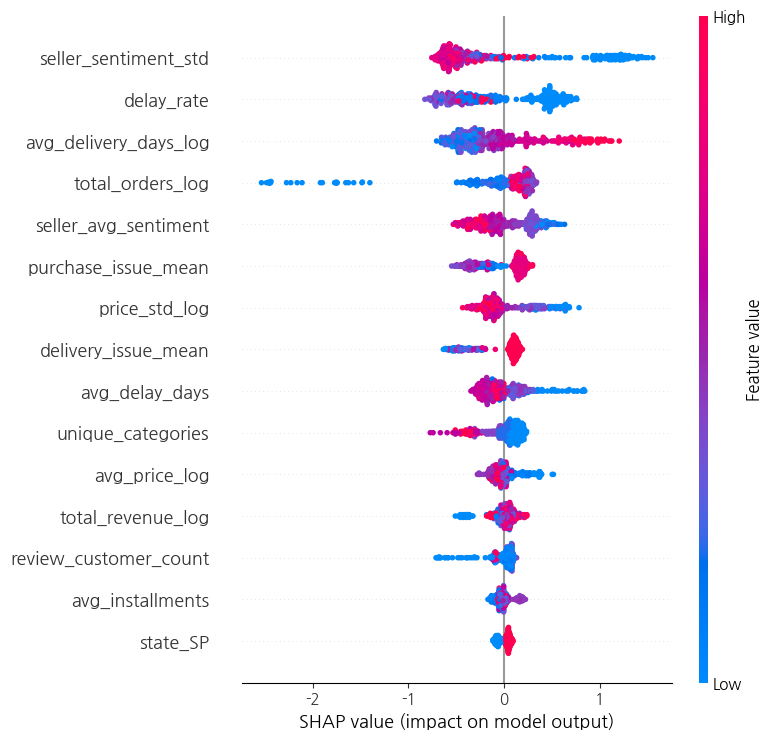

In [ ]:
import shap

# TreeExplainer 생성 + SHAP value 계산
explainer = shap.TreeExplainer(final_model)  # calibration 전 원본 XGBoost 모델 사용
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

# Summary Plot (전역 해석 — 발표 핵심 그림)
shap.summary_plot(shap_values, X_test, max_display=15)

더미 개수 정상  

피처별 분포 고른 편 ~

<상위권 해석>
1. 1위 seller_sentiment_std (감성 변동성)  
빨강(값 높음)이 왼쪽(생존 방향), 파랑(값 낮음)이 오른쪽(이탈 방향)에 몰려있어요. 즉 감성 점수가 들쭉날쭉한(리뷰마다 반응이 크게 갈리는) 셀러가 오히려 이탈 위험이 낮고, 감성이 일관되게 낮은(변동 없이 계속 안 좋은) 셀러가 이탈 위험이 높다는 뜻. 꽤 흥미로운 인사이트: "가끔 실수해도 대체로 반응이 다양하게 갈리는 셀러"보다 "꾸준히 나쁜 평가만 받는 셀러"가 더 위험하다는 뜻

2. 2위 delay_rate (배송 지연 발생률)  
직관과 일치. 파랑(지연율 낮음)이 왼쪽, 빨강(지연율 높음)이 오른쪽 — 배송 지연이 잦을수록 이탈 위험 증가. 예상대로 나옴

3. 3위 avg_delivery_days_log (배송 소요일)  
마찬가지로 빨강(배송 오래 걸림)이 오른쪽(이탈 방향)에 넓게 퍼져있음. delay_rate와 함께, "배송 관련 지표가 셀러 생존에 핵심적인 영향을 준다"는 스토리가 두 피처에서 일관되게 나왔음

4. 4위 total_orders_log   
여전히 상위권이긴 하지만, 순위 자체는 4위로 내려옴. 왼쪽 끝에 파랑 점들이 몰려있음 — 극소량 주문 셀러가 이탈과 강하게 연결. "활동 기간이 짧아서 누적 주문이 적은 것"과 "정말 영세해서 위험한 것"이 섞여있을 수 있는 피처이므로 해석할 때 이 한계 무시하면 안 됨

<중하위권 중 눈에 띄는 것>
1. purchase_issue_mean, delivery_issue_mean: 리뷰 텍스트 기반 이슈 강도 — 빨강(이슈 많음)이 오른쪽(이탈 방향)으로, 연수가 만든 LDA/aspect 피처가 실제로 기여하고 있다는 게 확인됨!
2. price_std_log: 가격 일관성 — 빨강(가격 변동 큼)이 오른쪽 → 가격을 들쭉날쭉하게 매기는 셀러가 이탈 위험 높음
3. state_SP: 상파울루 지역 더미가 하위권이지만 유의미하게 나타남 — 지역 효과도 미세하게 있다는 신호

> 설문 시뮬레이터에 입력받을 항목 위주로 SHAP 분석  

배송지연율 같은 피처들은 셀러가 정하는게 아니라서 패스  

<후보>
- avg_delivery_days_log(배송 소요일)
- avg_price_log(가격대)
- unique_categories(취급 카테고리 수)
- avg_installments(할부)
- state_SP

## avg_delivery_days_log(배송 소요일)

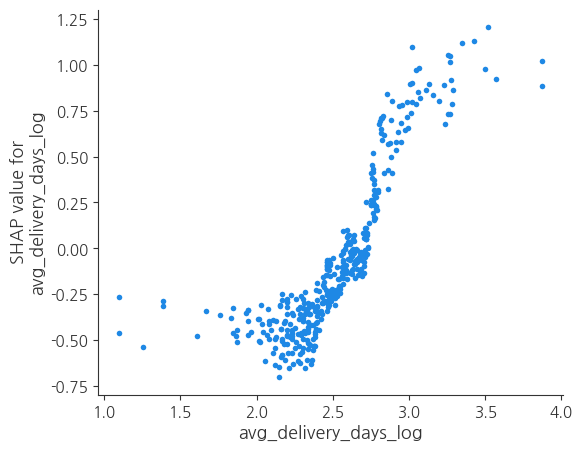

In [ ]:
shap.dependence_plot('avg_delivery_days_log', shap_values, X_test, interaction_index=None)

약간 변곡점 보임. 약 2.5 근처 ...

배송일수 로그변환축이라 실제일수로 다시변환해서 관찰

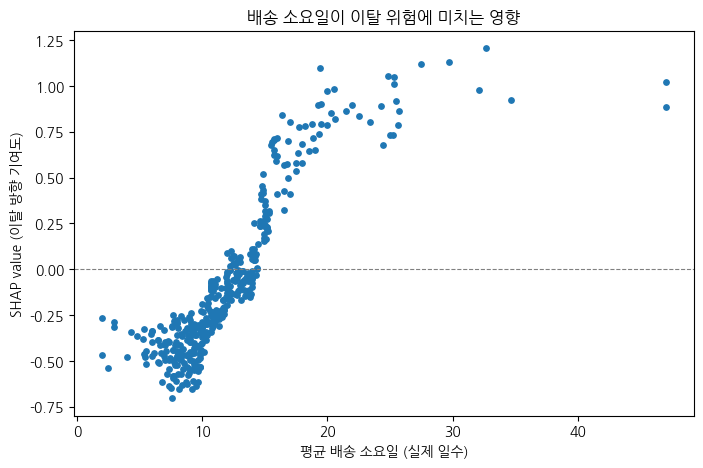

SHAP value가 0을 넘어가는 근처 배송일수 확인:
       actual_days  shap_value
count        94.00       94.00
mean         13.28        0.04
std           1.28        0.11
min          10.69       -0.10
25%          12.50       -0.05
50%          13.25       -0.00
75%          14.27        0.10
max          15.26        0.29


In [ ]:
import numpy as np

# 로그변환 역산: log1p였으니 expm1로 복원
actual_days = np.expm1(X_test['avg_delivery_days_log'])

shap.dependence_plot(
    'avg_delivery_days_log', shap_values, X_test,
    interaction_index=None,
    show=False
)
import matplotlib.pyplot as plt
plt.close()  # 위 plot 안 띄우고 아래서 실제 일수로 다시 그림

plt.figure(figsize=(8,5))
plt.scatter(actual_days, shap_values[:, list(X_test.columns).index('avg_delivery_days_log')], s=15)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('평균 배송 소요일 (실제 일수)')
plt.ylabel('SHAP value (이탈 방향 기여도)')
plt.title('배송 소요일이 이탈 위험에 미치는 영향')
plt.show()

# 꺾이는 지점 근처 값 확인
print("SHAP value가 0을 넘어가는 근처 배송일수 확인:")
temp_df = pd.DataFrame({
    'actual_days': actual_days,
    'shap_value': shap_values[:, list(X_test.columns).index('avg_delivery_days_log')]
}).sort_values('actual_days')
print(temp_df[(temp_df['shap_value'] > -0.1) & (temp_df['shap_value'] < 0.3)].describe())

생존/이탈 전환 기준 SHAP 값=0을 지나는 지점이 12~13일 근처인듯  

- 7일 이하: 음수! 빠른배송이 셀러 생존에 강한 기여
- 7~12일: 0 근처, 완만한 상승. 중립-약간 위험한 정도
- 12일 초과: 급경사, 급격 양수 ... 배송 늦어질수록 이탈 위험 급증

**"셀러가 통제 가능한 배송 속도가 12일이라는 특정 지점을 넘으면 위험이 급증한다"** 라는 패턴.
단 '실제로 걸린 기간'이기 때문에 해석 주의 필요하긴 함.  

> 시뮬레이터 반영 전략
배송 소요일 입력 옵션 → 1~5점 배점  

───────────────────────

1 ~ 7일    → 5점 (안전 구간, SHAP 뚜렷한 음수)  
8 ~ 11일   → 4점 (완만한 전환 구간)  
12 ~ 14일  → 2점 (급경사 시작점)  
15 ~ 20일  → 1점 (위험 구간)  
21일 이상 → 0점 (SHAP 최댓값 근접 구간)



## avg_price_log(가격대)


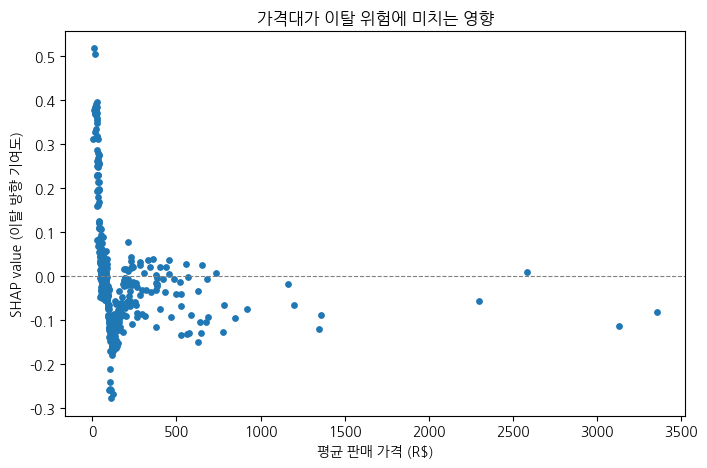

       actual_price  shap_value
count        306.00      306.00
mean         182.03        0.01
std          320.40        0.09
min           27.22       -0.10
25%           53.67       -0.04
50%           79.51       -0.01
75%          194.59        0.03
max        3,360.00        0.29


In [ ]:
actual_price = np.expm1(X_test['avg_price_log'])
price_idx = list(X_test.columns).index('avg_price_log')

plt.figure(figsize=(8,5))
plt.scatter(actual_price, shap_values[:, price_idx], s=15)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('평균 판매 가격 (R$)')
plt.ylabel('SHAP value (이탈 방향 기여도)')
plt.title('가격대가 이탈 위험에 미치는 영향')
plt.show()

# 0을 넘는 지점 근처 가격대 확인
temp_df = pd.DataFrame({
    'actual_price': actual_price,
    'shap_value': shap_values[:, price_idx]
}).sort_values('actual_price')
print(temp_df[(temp_df['shap_value'] > -0.1) & (temp_df['shap_value'] < 0.3)].describe())

가격은 뚜렷한 임계점이 있는게 아님.  
가격 극단값이 좀 있음, 저가 구간 변동성 관찰 필요!  
그리고 가격 낮고/높은 거랑 상관없이 ... 다른 피처랑 상호작용일 가능성이 높은듯


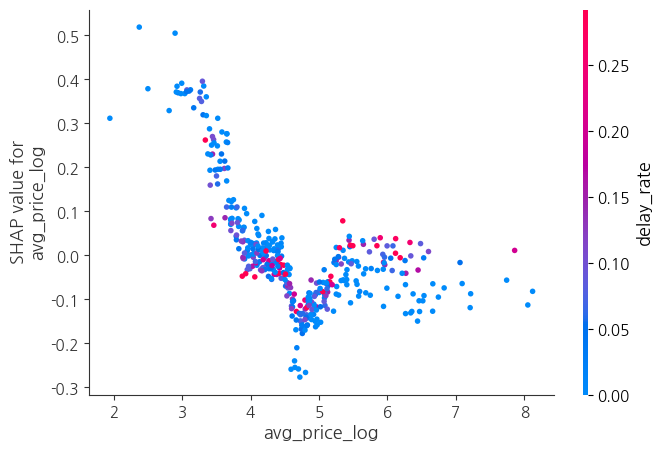

In [ ]:
shap.dependence_plot(
    'avg_price_log', shap_values, X_test,
    interaction_index='auto'  # SHAP이 자동으로 가장 상호작용 강한 피처를 찾아서 색칠해줌
)

다시 log로 관찰, 제일 상호작용 강한 피처는 배송지연율이었음.  
- 매우 저가: 이탈 위험 경향 있음
- 중간 가격대: 가장 안전
- 고가: 다시 0 근처로 이동(음수가 더 많긴함)  

인사이트 : **극단적으로 싸거나 극단적으로 비싼 가격 전략이 위험하고, 90~150R$대의 중간 가격이 가장 안정적**




95th percentile 가격: 613R$


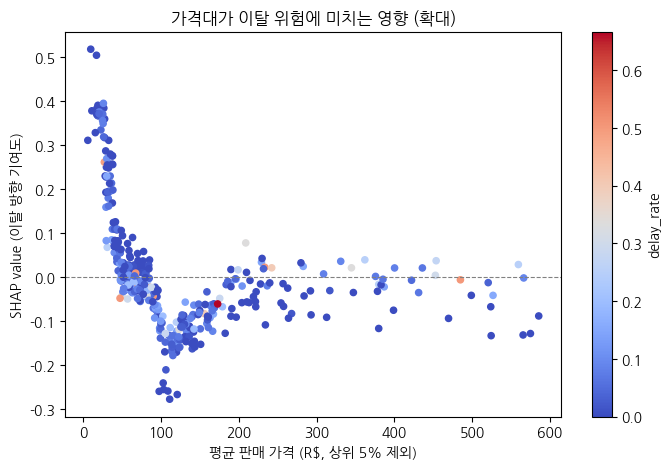

In [ ]:
# 표본이 몰린 구간(하위 95%)만 필터링해서 재확인
price_cutoff = np.percentile(actual_price, 95)
print(f"95th percentile 가격: {price_cutoff:.0f}R$")

mask = actual_price <= price_cutoff

plt.figure(figsize=(8,5))
scatter = plt.scatter(
    actual_price[mask], shap_values[mask, price_idx],
    c=X_test['delay_rate'][mask], cmap='coolwarm', s=20
)
plt.colorbar(scatter, label='delay_rate')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('평균 판매 가격 (R$, 상위 5% 제외)')
plt.ylabel('SHAP value (이탈 방향 기여도)')
plt.title('가격대가 이탈 위험에 미치는 영향 (확대)')
plt.show()

극단값 제외, 가격 로그변환X  
저가/중가/고가 구간별 경계 확인용  

- 저가(0~50): 거의 색도 진한 파랑(배송 빠름)인데 이탈 위험 큼... 너무 싸게 팔면 망한다?
- 최저점(100~150): 가장 안전
- 150~160: 0 근처에서 넓게 흩어짐 ... 여기 이후부터는 가격 자체보다 다른 요인이 더 크게 관여.   


> 시뮬레이터 반영 전략: 너무 낮으면 위험, 적정선이 안전, 그 이상은 불확실  
가격대 입력 옵션 → 점수 매핑
─────────────────────────────────
-50     → 1점 (뚜렷한 위험 구간, 박리다매 리스크)  
50-100  → 3점 (전환 구간)  
100-150 → 5점 (SHAP 최저점, 가장 안전한 스위트 스팟)  
150-300 → 3점 (불확실 구간, 다른 요소 영향 커짐)  
300~    → 2점 (표본 적고 산발적, 보수적으로 낮게)  



## unique_categories(취급 카테고리 수)


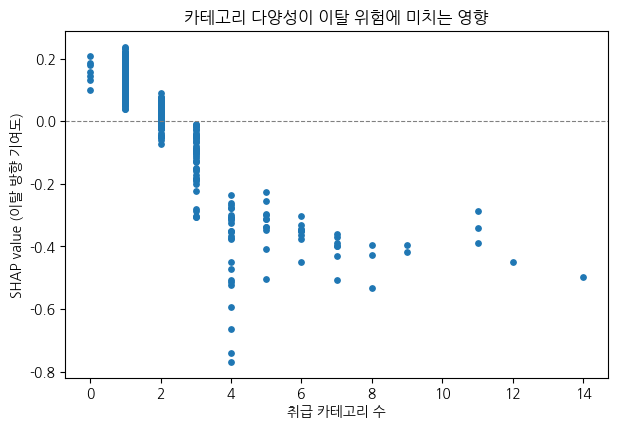

                   mean  count
unique_categories             
0                  0.16      7
1                  0.13    203
2                  0.02     84
3                 -0.11     49
4                 -0.41     26
5                 -0.33     11
6                 -0.36     10
7                 -0.41      7
8                 -0.45      3
9                 -0.41      2
11                -0.34      3
12                -0.45      1
14                -0.50      1


In [ ]:
idx = list(X_test.columns).index('unique_categories')

plt.figure(figsize=(7,4.5))
plt.scatter(X_test['unique_categories'], shap_values[:, idx], s=15)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('취급 카테고리 수')
plt.ylabel('SHAP value (이탈 방향 기여도)')
plt.title('카테고리 다양성이 이탈 위험에 미치는 영향')
plt.show()

temp_df = pd.DataFrame({
    'unique_categories': X_test['unique_categories'],
    'shap_value': shap_values[:, idx]
})
print(temp_df.groupby('unique_categories')['shap_value'].agg(['mean','count']).sort_index())

거의 계단식의 뚜렷한 패턴.  

0 ~ 1개 카테고리:  SHAP +0.15 ~ 0.16 (위험 방향)  
2개:            SHAP + 0.06 (약한 위험)  
3개:            SHAP - 0.14 (약한 안전, 전환점)  
4개 이상:        SHAP -0.55 ~ -0.72 (뚜렷한 안전, 여기서부터 평탄)  

단일 품목 파는 셀러가 위험.  
다양하게 취급하면 이탈 위험 감소! 다다익선이라기보단 4개 이상이기만 하면 이탈위험 급감.

> 시뮬레이터 반영 전략: 4개면 충분  

취급 카테고리 수 → 점수 매핑

─────────────────────────

1개    → 1점 (위험 구간)  
2개    → 2점 (약한 위험)  
3개    → 4점 (전환점, 안전 쪽으로)  
4개 이상 → 5점 (충분히 안전, 그 이상 늘려도 큰 의미 없음)  

카테고리수 늘릴수록 고배점이라, 카테고리 관리 비용 등은 총배점에서 손해봐야함 ㅎ 트레이드오프 관계라 ㄱㅊ을 듯





## avg_installments(할부)


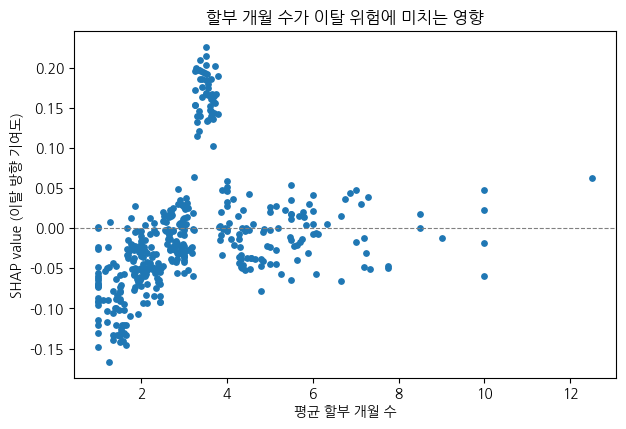

                  mean  count
avg_installments             
(0, 1]           -0.07     22
(1, 2]           -0.07     90
(2, 3]           -0.02    116
(3, 4]            0.10     84
(4, 5]           -0.02     40
(5, 6]           -0.00     29
(6, 8]           -0.01     18
(8, 10]          -0.00      7
(10, 15]          0.06      1


/tmp/ipykernel_682/2293054407.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(temp_df.groupby(pd.cut(temp_df['avg_installments'], bins=[0,1,2,3,4,5,6,8,10,15]))['shap_value'].agg(['mean','count']))


In [ ]:
idx = list(X_test.columns).index('avg_installments')

plt.figure(figsize=(7,4.5))
plt.scatter(X_test['avg_installments'], shap_values[:, idx], s=15)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('평균 할부 개월 수')
plt.ylabel('SHAP value (이탈 방향 기여도)')
plt.title('할부 개월 수가 이탈 위험에 미치는 영향')
plt.show()

temp_df = pd.DataFrame({
    'avg_installments': X_test['avg_installments'],
    'shap_value': shap_values[:, idx]
})
print(temp_df.groupby(pd.cut(temp_df['avg_installments'], bins=[0,1,2,3,4,5,6,8,10,15]))['shap_value'].agg(['mean','count']))

대체로 0 이하인데 왜 3~4개월 근처에서만??? 극단값???  

-> 브라질에서는 3개월 할부가 가장 흔한 표준 옵션이라고 함 -> 여기에 대부분의 셀러 표본이 치우쳐졌을 가능성 존재... 확인해보자!

3~4개월 구간 표본 수: 84
이 구간 churned 비율: 0.3333333333333333
전체 churned 비율: 0.3759213759213759


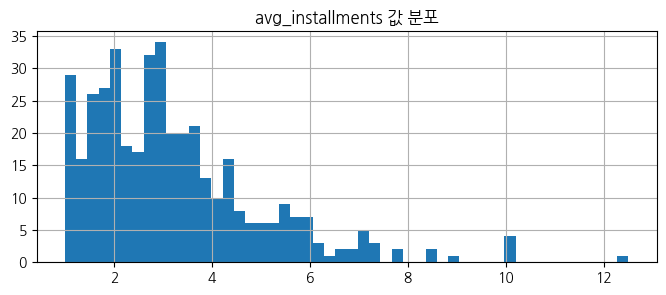

In [ ]:
# 3~4구간의 실제 이탈 여부 분포 확인 (churned 컬럼과 매칭)
mask_34 = (X_test['avg_installments'] > 3) & (X_test['avg_installments'] <= 4)
print("3~4개월 구간 표본 수:", mask_34.sum())
print("이 구간 churned 비율:", y_test[mask_34].mean())
print("전체 churned 비율:", y_test.mean())

# 값 분포 자체도 확인
X_test['avg_installments'].hist(bins=50, figsize=(8,3))
plt.title('avg_installments 값 분포')
plt.show()

3~4개월 이탈률이 평균 이탈률보다 낮은데 왜이렇게 스파이크가 나오지  
모순 발생 .... 그냥 다른 피처들 간 상호작용 속에서 나오는 이상한 SHAP 해석값일 수 있음.  
-> 시뮬레이터에서 제외하자!  


## state_SP(상파울루 지역)  

SHAP Summary plot에서 유일한 지역 더미.  
브라질에서 상파울루(SP)는 셀러가 압도적으로 몰려있는 지역임(데이터셋 기준 전체의 절반 이상.)   

(참고)  
원-핫 인코딩할 때 seller_state_grouped(재그룹핑 후 SP, PR, MG, SC, RJ, RS, 기타 7개 카테고리)를 drop_first=True로 더미화. 그 결과 알파벳/생성 순서상 SP를 제외한 나머지 6개만 실제 컬럼으로 만들어짐 (drop_first가 첫 번째 카테고리를 기준값으로 삼고 제거해서)

정확히는 SP가 아니라, 나머지 지역들의 더미가 있는 것! pd.get_dummies(..., drop_first=True)를 쓰면 카테고리 하나(보통 알파벳순 첫 번째)가 자동으로 빠지고, 그게 "기준(baseline)"이 됨. state 알파벳 순서를 보면 기타, MG, PR, RJ, RS, SC, SP 중 기타가 알파벳/가나다상 먼저 와서 baseline으로 빠졌어야 하는데... 실제로 만들어진 컬럼 목록을 다시 보면 state_SP가 있고 나머지 6개도 있었으니, 사실 drop된 건 기타이고, state_SP는 정상적으로 남은 6개 더미 중 하나.

즉 지금 모델은 "이 셀러가 SP 지역인가 아닌가(1/0)"를 하나의 독립된 피처로 갖고 있고, 이게 Summary Plot에서 하위권이지만 중요도가 잡혔던 것으로 해석. "SP가 특별히 중요해서"가 아니라, 실제로 X에 존재하는 유일한 지역 피처라서 확인 대상으로 여김


---

그러면 ... SP여부만 보는건 어폐 있음. 지역 다 쪼개서 보자

In [ ]:
state_cols = [c for c in X_test.columns if c.startswith('state_')]
state_col_idx = [list(X_test.columns).index(c) for c in state_cols]

# 셀러별로 state 관련 더미들의 SHAP value 총합 (실질적인 "지역 전체 기여도")
state_total_shap = shap_values[:, state_col_idx].sum(axis=1)

temp_df = pd.DataFrame({
    'seller_state_grouped': final_df.loc[X_test.index, 'seller_state_grouped'],
    'state_shap_total': state_total_shap
})

print(temp_df.groupby('seller_state_grouped')['state_shap_total'].agg(['mean','count']).sort_values('mean'))

                      mean  count
seller_state_grouped             
RS                   -0.17     12
DF                   -0.08      2
SC                   -0.07     26
PR                   -0.07     48
기타                   -0.07     13
RJ                   -0.00     15
MG                    0.02     34
SP                    0.05    257


- 안전 방향 (음수, 표본 충분): RS(-0.26, n=12) → PR(-0.17, n=48) → SC(-0.15, n=26) → 기타(-0.13, n=13) → MG(-0.08, n=34)  
- 위험 방향 (양수):            RJ(+0.01, n=15) → SP(+0.10, n=257)


그렇다고 지역별 미세한 순위 차이가 있다고 보기는 어려움.  
표본 크기가 지역마다 크게 다르긴 함 ... SP는 위험 / 그외 안전 2진 분류? 그럼 너무 다양성 떨어짐  

> 표본 늘려서 다시 계산

train + test 합쳐서 계산, 지역별 표본 약 5배 늘어남  


In [ ]:
# 전체 데이터 SHAP 계산
shap_values_full = explainer.shap_values(X)

state_cols = [c for c in X.columns if c.startswith('state_')]
state_col_idx = [list(X.columns).index(c) for c in state_cols]

state_total_shap_full = shap_values_full[:, state_col_idx].sum(axis=1)

temp_df_full = pd.DataFrame({
    'seller_state_grouped': final_df['seller_state_grouped'],
    'state_shap_total': state_total_shap_full
})

# 평균, 표준오차 - 신뢰도 확인
summary = temp_df_full.groupby('seller_state_grouped')['state_shap_total'].agg(['mean','std','count'])
summary['se'] = summary['std'] / np.sqrt(summary['count'])  # 표준오차
print(summary.sort_values('mean'))

                      mean  std  count   se
seller_state_grouped                       
RS                   -0.17 0.03     79 0.00
SC                   -0.07 0.02    116 0.00
기타                   -0.07 0.02     70 0.00
PR                   -0.07 0.02    236 0.00
DF                   -0.06 0.02     26 0.00
RJ                   -0.00 0.02    103 0.00
MG                    0.00 0.06    161 0.00
SP                    0.05 0.02   1240 0.00


표준오차 매우 작음 ! 실제로도 유의미한 차이 있는 듯?   

----
시드고정 안 했더니 optuna 파라미터 조합 달라져서 수치가 좀 달라짐 ..............
아 .....
그래도 전체적 SHAP 분석경향은 유지되긴 함

> optuna sampler 시드 고정, 재탐색

In [ ]:
import optuna

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

[I 2026-07-31 07:34:16,948] A new study created in memory with name: no-name-15d4c053-afa6-4a55-9c9b-1923a5da1508


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-31 07:34:18,087] Trial 0 finished with value: 0.6863187086269067 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.07441632389160634, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 0.6863187086269067.
[I 2026-07-31 07:34:18,842] Trial 1 finished with value: 0.6946484663482648 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.17898794163735265, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.6237821581611893}. Best is trial 1 with value: 0.6946484663482648.
[I 2026-07-31 07:34:19,619] Trial 2 finished with value: 0.6751601702546342 and parameters: {'n_estimators': 273, 'max_depth': 4, 'learning_rate': 0.04777437867054351, 'subsample': 0.6

> XGBoost 재학습

In [ ]:
final_params = study.best_params
final_params.update({'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42})
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6933658006686138, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=1.5684998616625434, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.06971249457112637,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=327, n_jobs=None,
              num_parallel_tree=None, ...)

> Calibration 다시 적용

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(final_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

y_pred = calibrated_model.predict(X_test)
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import f1_score, roc_auc_score
print("F1:", round(f1_score(y_test, y_pred), 3))
print("AUC:", round(roc_auc_score(y_test, y_proba), 3))

F1: 0.698
AUC: 0.838


> 지역 SHAP 재계산

In [ ]:
explainer = shap.TreeExplainer(final_model)
shap_values_full = explainer.shap_values(X)  # X 전체

state_cols = [c for c in X.columns if c.startswith('state_')]
state_col_idx = [list(X.columns).index(c) for c in state_cols]
state_total_shap_full = shap_values_full[:, state_col_idx].sum(axis=1)

temp_df_full = pd.DataFrame({
    'seller_state_grouped': final_df['seller_state_grouped'],
    'state_shap_total': state_total_shap_full
})
summary = temp_df_full.groupby('seller_state_grouped')['state_shap_total'].agg(['mean','std','count'])
summary['se'] = summary['std'] / np.sqrt(summary['count'])
print(summary.sort_values('mean'))

                      mean  std  count   se
seller_state_grouped                       
RS                   -0.30 0.04     79 0.00
PR                   -0.09 0.03    236 0.00
SC                   -0.09 0.03    116 0.00
기타                   -0.08 0.03     70 0.00
DF                   -0.07 0.03     26 0.00
MG                   -0.01 0.06    161 0.00
RJ                    0.04 0.03    103 0.00
SP                    0.05 0.02   1240 0.00


오히려 좋아(?)  
인사이트: 지역별 값 순위는 유사한데, 모델 자체가 재학습 될 때마다 SHAP 지수 차이가 좀 달라지긴 함. -> 굵직한 경계만 나누기.   

> 시뮬레이터 반영 전략  

RS               → 5점 (뚜렷하게 가장 안전, 일관됨)
PR, SC, 기타, DF   → 4점 (안전 그룹, 서로 세분화할 근거 부족)
MG               → 3점 (중립, 안전과 위험의 경계)
RJ, SP           → 1점 (위험 그룹, 둘 사이 차이는 불안정해서 하나로 묶음)

## 추가 확인

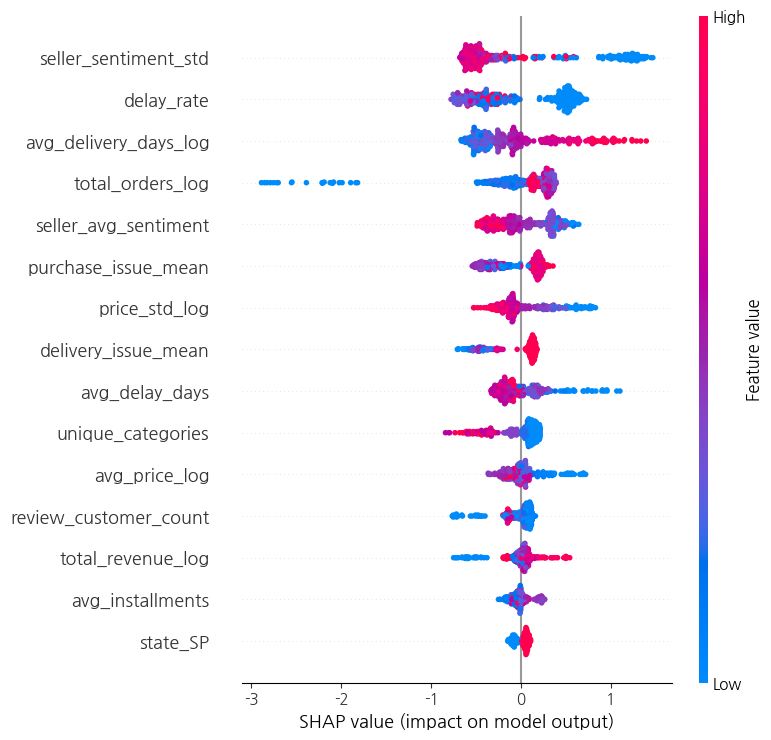

In [ ]:
# Summary plot 재확인 (전체 순위 크게 안 변했는지)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, max_display=15)

> 시드 고정 이전/이후 비교 및 재검증

그래프 추세 보니까 다 기존작성 코멘트랑 크게 달라지지 않아서 괜찮을듯함! 그대로 유지 !

## 결론

시뮬레이터 반영 피처 4종류
1. 배송 소요일
2. 가격대
3. 취급 카테고리 수
4. 판매 지역

총점 제한 방식 채택.  
항목별 1~5점 배점 후 총점 상한 설정 (예: 총 20점 만점 중 15점 이하만 허용) → 모든 항목에서 최고점을 고르지 못하게 해 트레이드오프 유도. 상한선 구체적 숫자는 UI 설계 단계에서 결정.  